In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import matplotlib.pyplot as plt
import pandas as pd

Create Spark Session

In [2]:
spark = (
    SparkSession.builder
    .appName("Risk Zone Scoring")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

26/07/31 00:59:37 WARN Utils: Your hostname, LAPTOP-S89A4J3G resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/31 00:59:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/31 00:59:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/31 00:59:40 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
df = spark.read.csv(
    "../cleaned_data/road_accident_cleaned",
    header=True,
    inferSchema=True
)

In [4]:
print("Rows :", df.count())
print("Columns :", len(df.columns))

df.printSchema()

Rows : 300491
Columns : 23
root
 |-- Accident_Index: string (nullable = true)
 |-- Accident Date: date (nullable = true)
 |-- Month: string (nullable = true)
 |-- Day_of_Week: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Junction_Control: string (nullable = true)
 |-- Junction_Detail: string (nullable = true)
 |-- Accident_Severity: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Light_Conditions: string (nullable = true)
 |-- Local_Authority_(District): string (nullable = true)
 |-- Carriageway_Hazards: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Number_of_Casualties: integer (nullable = true)
 |-- Number_of_Vehicles: integer (nullable = true)
 |-- Police_Force: string (nullable = true)
 |-- Road_Surface_Conditions: string (nullable = true)
 |-- Road_Type: string (nullable = true)
 |-- Speed_limit: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Urban_or_Rural_Area: string (nullable = true)
 |


Select Required Columns

In [5]:
risk_df = df.select(
    "Local_Authority_(District)",
    "Latitude",
    "Longitude",
    "Accident_Severity",
    "Number_of_Casualties"
)

risk_df.show(5)

+--------------------------+---------+---------+-----------------+--------------------+
|Local_Authority_(District)| Latitude|Longitude|Accident_Severity|Number_of_Casualties|
+--------------------------+---------+---------+-----------------+--------------------+
|      Kensington and Ch...|51.486145|-0.180628|           Slight|                   1|
|      Kensington and Ch...|51.492829| -0.17676|           Slight|                   1|
|            City of London|51.510703| -0.08511|           Slight|                   1|
|               Westminster| 51.49267|-0.138015|           Slight|                   1|
|               Westminster|51.485691|-0.134555|           Slight|                   1|
+--------------------------+---------+---------+-----------------+--------------------+
only showing top 5 rows



In [6]:
risk_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in risk_df.columns
]).show()

+--------------------------+--------+---------+-----------------+--------------------+
|Local_Authority_(District)|Latitude|Longitude|Accident_Severity|Number_of_Casualties|
+--------------------------+--------+---------+-----------------+--------------------+
|                         0|       0|        0|                0|                   0|
+--------------------------+--------+---------+-----------------+--------------------+



Create Severity Score Variable

In [7]:
risk_df = risk_df.withColumn(
    "Severity_Score",
    when(col("Accident_Severity") == "Fatal", 10)
    .when(col("Accident_Severity") == "Serious", 5)
    .otherwise(1)
)

risk_df.select(
    "Accident_Severity",
    "Severity_Score"
).show(10, truncate=False)

+-----------------+--------------+
|Accident_Severity|Severity_Score|
+-----------------+--------------+
|Slight           |1             |
|Slight           |1             |
|Slight           |1             |
|Slight           |1             |
|Slight           |1             |
|Serious          |5             |
|Slight           |1             |
|Slight           |1             |
|Slight           |1             |
|Slight           |1             |
+-----------------+--------------+
only showing top 10 rows



Aggregate by Location

In [8]:
risk_df = (
    risk_df
    .withColumn("Latitude", round(col("Latitude"), 3))
    .withColumn("Longitude", round(col("Longitude"), 3))
)

risk_df.show(5)

+--------------------------+--------+---------+-----------------+--------------------+--------------+
|Local_Authority_(District)|Latitude|Longitude|Accident_Severity|Number_of_Casualties|Severity_Score|
+--------------------------+--------+---------+-----------------+--------------------+--------------+
|      Kensington and Ch...|  51.486|   -0.181|           Slight|                   1|             1|
|      Kensington and Ch...|  51.493|   -0.177|           Slight|                   1|             1|
|            City of London|  51.511|   -0.085|           Slight|                   1|             1|
|               Westminster|  51.493|   -0.138|           Slight|                   1|             1|
|               Westminster|  51.486|   -0.135|           Slight|                   1|             1|
+--------------------------+--------+---------+-----------------+--------------------+--------------+
only showing top 5 rows



In [9]:
location_df = (
    risk_df
    .groupBy(
        "Local_Authority_(District)",
        "Latitude",
        "Longitude"
    )
    .agg(
        count("*").alias("Accident_Count"),
        sum("Number_of_Casualties").alias("Total_Casualties"),
        round(avg("Severity_Score"), 2).alias("Average_Severity")
    )
)

Check Number of Risk Zones

In [10]:
print("Total Risk Zones:", location_df.count())

Total Risk Zones: 211817


View Top Locations by Accident Count

In [11]:
location_df.orderBy(
    col("Accident_Count").desc()
).show(10, truncate=False)

+--------------------------+--------+---------+--------------+----------------+----------------+
|Local_Authority_(District)|Latitude|Longitude|Accident_Count|Total_Casualties|Average_Severity|
+--------------------------+--------+---------+--------------+----------------+----------------+
|Barnet                    |51.59   |-0.2     |36            |54              |1.44            |
|Hackney                   |51.571  |-0.096   |35            |47              |1.8             |
|Tower Hamlets             |51.525  |-0.035   |30            |34              |1.67            |
|Southwark                 |51.495  |-0.101   |29            |30              |1.55            |
|Tower Hamlets             |51.52   |-0.056   |27            |31              |1.59            |
|Birmingham                |52.459  |-1.871   |25            |38              |1.48            |
|Westminster               |51.501  |-0.126   |25            |27              |1.84            |
|Lewisham                  |51

Normalize the Variables

In [12]:
from pyspark.sql.functions import min, max, col

stats = location_df.select(
    min("Accident_Count").alias("min_acc"),
    max("Accident_Count").alias("max_acc"),
    min("Average_Severity").alias("min_sev"),
    max("Average_Severity").alias("max_sev"),
    min("Total_Casualties").alias("min_cas"),
    max("Total_Casualties").alias("max_cas")
).collect()[0]

stats

Row(min_acc=1, max_acc=36, min_sev=1.0, max_sev=10.0, min_cas=1, max_cas=54)

In [13]:
location_df = (
    location_df
    .withColumn(
        "Norm_Accidents",
        (col("Accident_Count") - stats["min_acc"]) /
        (stats["max_acc"] - stats["min_acc"])
    )
    .withColumn(
        "Norm_Severity",
        (col("Average_Severity") - stats["min_sev"]) /
        (stats["max_sev"] - stats["min_sev"])
    )
    .withColumn(
        "Norm_Casualties",
        (col("Total_Casualties") - stats["min_cas"]) /
        (stats["max_cas"] - stats["min_cas"])
    )
)

location_df.show(5)

+--------------------------+--------+---------+--------------+----------------+----------------+------------------+-------------------+--------------------+
|Local_Authority_(District)|Latitude|Longitude|Accident_Count|Total_Casualties|Average_Severity|    Norm_Accidents|      Norm_Severity|     Norm_Casualties|
+--------------------------+--------+---------+--------------+----------------+----------------+------------------+-------------------+--------------------+
|                     Brent|  51.555|   -0.228|             1|               1|             1.0|               0.0|                0.0|                 0.0|
|                    Ealing|   51.55|   -0.318|             1|               1|             1.0|               0.0|                0.0|                 0.0|
|               Westminster|  51.507|   -0.142|             8|               8|            3.13|               0.2|0.23666666666666666|  0.1320754716981132|
|                   Hackney|  51.547|   -0.055|           

Calculate Risk Score

In [14]:
from pyspark.sql.functions import round, col

location_df = (
    location_df
    .withColumn(
        "Risk_Score",
        round(
            (0.60 * col("Norm_Accidents")) +
            (0.25 * col("Norm_Severity")) +
            (0.15 * col("Norm_Casualties")),
            4
        )
    )
)

location_df.select(
    "Latitude",
    "Longitude",
    "Accident_Count",
    "Average_Severity",
    "Total_Casualties",
    "Risk_Score"
).show(10, truncate=False)

+--------+---------+--------------+----------------+----------------+----------+
|Latitude|Longitude|Accident_Count|Average_Severity|Total_Casualties|Risk_Score|
+--------+---------+--------------+----------------+----------------+----------+
|51.555  |-0.228   |1             |1.0             |1               |0.0       |
|51.55   |-0.318   |1             |1.0             |1               |0.0       |
|51.507  |-0.142   |8             |3.13            |8               |0.199     |
|51.547  |-0.055   |10            |2.2             |16              |0.2301    |
|51.582  |0.109    |1             |1.0             |2               |0.0028    |
|51.513  |-0.42    |2             |1.0             |2               |0.02      |
|51.49   |-0.207   |1             |5.0             |1               |0.1111    |
|54.678  |-1.781   |1             |1.0             |1               |0.0       |
|53.75   |-2.499   |1             |5.0             |1               |0.1111    |
|53.392  |-2.96    |6       

Create Risk Levels

In [15]:
location_df = (
    location_df
    .withColumn(
        "Risk_Level",
        when(col("Risk_Score") >= 0.25, "High")
        .when(col("Risk_Score") >= 0.10, "Medium")
        .otherwise("Low")
    )
)

location_df.select(
    "Risk_Score",
    "Risk_Level"
).show(10)

+----------+----------+
|Risk_Score|Risk_Level|
+----------+----------+
|       0.0|       Low|
|       0.0|       Low|
|     0.199|    Medium|
|    0.2301|    Medium|
|    0.0028|       Low|
|      0.02|       Low|
|    0.1111|    Medium|
|       0.0|       Low|
|    0.1111|    Medium|
|    0.1225|    Medium|
+----------+----------+
only showing top 10 rows



In [16]:
location_df.groupBy("Risk_Level").count().show()

+----------+------+
|Risk_Level| count|
+----------+------+
|      High|  2776|
|       Low|179162|
|    Medium| 29879|
+----------+------+



In [17]:
location_df.orderBy(col("Risk_Score").desc()).show(20, truncate=False)

+--------------------------+--------+---------+--------------+----------------+----------------+------------------+--------------------+-------------------+----------+----------+
|Local_Authority_(District)|Latitude|Longitude|Accident_Count|Total_Casualties|Average_Severity|Norm_Accidents    |Norm_Severity       |Norm_Casualties    |Risk_Score|Risk_Level|
+--------------------------+--------+---------+--------------+----------------+----------------+------------------+--------------------+-------------------+----------+----------+
|Barnet                    |51.59   |-0.2     |36            |54              |1.44            |1.0               |0.048888888888888885|1.0                |0.7622    |High      |
|Hackney                   |51.571  |-0.096   |35            |47              |1.8             |0.9714285714285714|0.08888888888888889 |0.8679245283018868 |0.7353    |High      |
|Tower Hamlets             |51.525  |-0.035   |30            |34              |1.67            |0.8285714

Attach District Name to Each Risk Zone

Top 20 Highest Risk Zones

In [19]:
top_risk = (
    location_df
    .orderBy(
        col("Risk_Score").desc(),
        col("Accident_Count").desc()
    )
)

top_risk.select(
    "Local_Authority_(District)",
    "Latitude",
    "Longitude",
    "Accident_Count",
    "Total_Casualties",
    "Average_Severity",
    "Risk_Score",
    "Risk_Level"
).show(20, truncate=False)

+--------------------------+--------+---------+--------------+----------------+----------------+----------+----------+
|Local_Authority_(District)|Latitude|Longitude|Accident_Count|Total_Casualties|Average_Severity|Risk_Score|Risk_Level|
+--------------------------+--------+---------+--------------+----------------+----------------+----------+----------+
|Barnet                    |51.59   |-0.2     |36            |54              |1.44            |0.7622    |High      |
|Hackney                   |51.571  |-0.096   |35            |47              |1.8             |0.7353    |High      |
|Tower Hamlets             |51.525  |-0.035   |30            |34              |1.67            |0.6092    |High      |
|Southwark                 |51.495  |-0.101   |29            |30              |1.55            |0.5774    |High      |
|Tower Hamlets             |51.52   |-0.056   |27            |31              |1.59            |0.547     |High      |
|Birmingham                |52.459  |-1.871   |2

In [20]:
top20 = (
    top_risk
    .limit(20)
    .toPandas()
)

top20

,Local_Authority_(District),Latitude,Longitude,Accident_Count,Total_Casualties,Average_Severity,Norm_Accidents,Norm_Severity,Norm_Casualties,Risk_Score,Risk_Level
0,Barnet,51.590,-0.200,36,54,1.44,1.000000,0.048889,1.000000,0.7622,High
1,Hackney,51.571,-0.096,35,47,1.80,0.971429,0.088889,0.867925,0.7353,High
2,Tower Hamlets,51.525,-0.035,30,34,1.67,0.828571,0.074444,0.622642,0.6092,High
3,Southwark,51.495,-0.101,29,30,1.55,0.800000,0.061111,0.547170,0.5774,High
4,Tower Hamlets,51.520,-0.056,27,31,1.59,0.742857,0.065556,0.566038,0.5470,High
5,Birmingham,52.459,-1.871,25,38,1.48,0.685714,0.053333,0.698113,0.5295,High
6,Westminster,51.501,-0.126,25,27,1.84,0.685714,0.093333,0.490566,0.5083,High
7,Lewisham,51.458,-0.013,25,30,1.48,0.685714,0.053333,0.547170,0.5068,High
8,Lambeth,51.463,-0.115,25,30,1.48,0.685714,0.053333,0.547170,0.5068,High
9,Newham,51.526,0.029,24,37,1.33,0.657143,0.036667,0.679245,0.5053,High


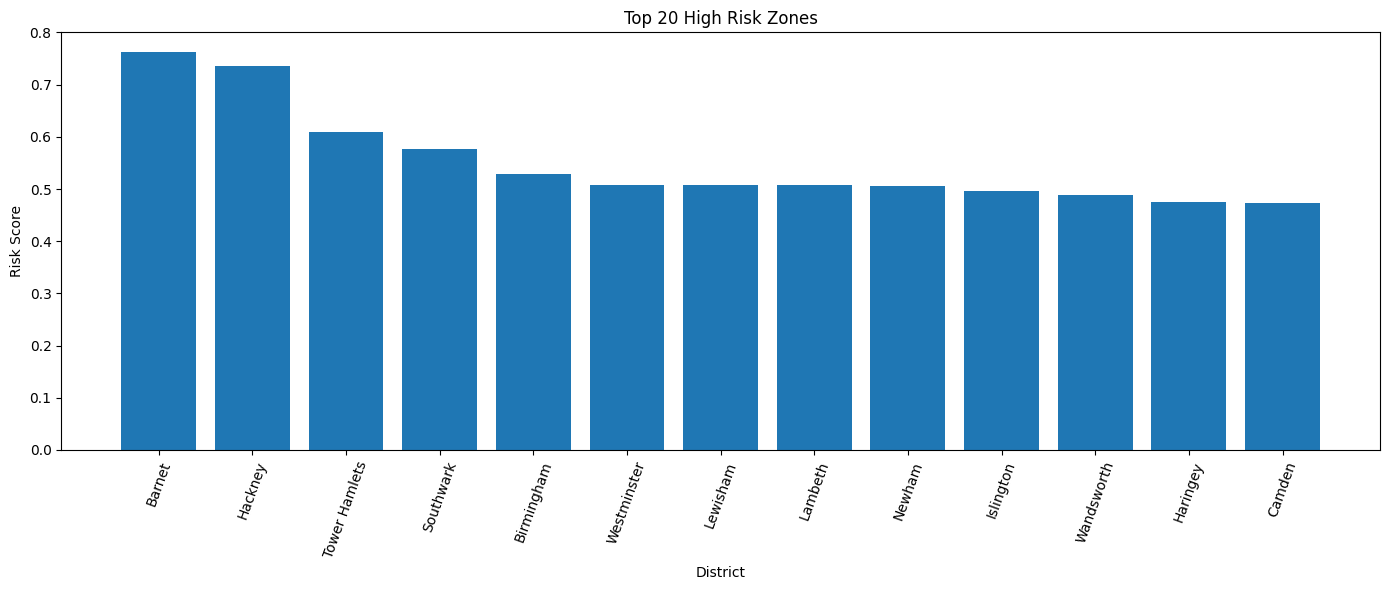

In [21]:
plt.figure(figsize=(14,6))

plt.bar(
    top20["Local_Authority_(District)"],
    top20["Risk_Score"]
)

plt.xticks(rotation=70)

plt.title("Top 20 High Risk Zones")
plt.xlabel("District")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.show()

Risk Level Distribution

In [22]:
risk_counts = (
    location_df
    .groupBy("Risk_Level")
    .count()
    .orderBy("Risk_Level")
    .toPandas()
)

risk_counts

,Risk_Level,count
0,High,2776
1,Low,179162
2,Medium,29879


Plot Risk Level Distribution

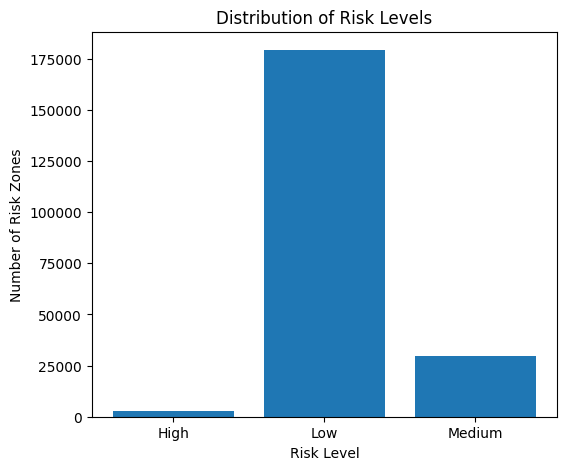

In [23]:
plt.figure(figsize=(6,5))

plt.bar(
    risk_counts["Risk_Level"],
    risk_counts["count"]
)

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Risk Zones")

plt.show()

Summary Statistics

In [24]:
location_df.select(
    "Risk_Score"
).describe().show()

+-------+--------------------+
|summary|          Risk_Score|
+-------+--------------------+
|  count|              211817|
|   mean|0.029059922480252246|
| stddev| 0.05028730954696857|
|    min|                 0.0|
|    max|              0.7622|
+-------+--------------------+



Save Output (Parquet)

In [25]:
location_df.write.mode("overwrite").parquet(
    "../outputs/risk_zone_scores"
)

Save Output (CSV)

In [26]:
location_df.coalesce(1).write.mode("overwrite") \
.option("header", True) \
.csv("../outputs/risk_zone_scores_csv")

## Conclusion

A Risk Zone Scoring framework was developed using PySpark to identify accident-prone locations based on historical road accident data. Geographic coordinates were grouped into unique locations using rounded latitude and longitude values, while the corresponding local authority district was retained for easier interpretation. A weighted Risk Score was computed using normalized accident frequency, average accident severity, and total casualties. Based on these scores, each location was classified into High, Medium, or Low risk categories. The analysis successfully identified major accident hotspots across different districts, providing valuable insights that can support traffic management, road safety planning, infrastructure improvements, and resource allocation.